In [2]:
# 1. INSTALL REQUIRED LIBRARIES


!pip install -q catboost lightgbm xgboost imbalanced-learn openpyxl


In [3]:
# 2. IMPORT LIBRARIES

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.utils import shuffle

from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.feature_selection import SelectKBest, f_classif

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline

from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    GradientBoostingClassifier,
    AdaBoostClassifier,
    StackingClassifier
)

from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

from sklearn.neural_network import (
    MLPClassifier,
    BernoulliRBM
)

from sklearn.model_selection import (
    cross_validate,
    train_test_split
)

from sklearn.metrics import roc_curve, auc

from sklearn.calibration import CalibratedClassifierCV

In [5]:
# ============================================================
# 3. MANUALLY UPLOAD DATASET
# ============================================================

from google.colab import files
import pandas as pd
from sklearn.utils import shuffle

# Upload Excel file
uploaded = files.upload()

# Get uploaded filename automatically
file_name = list(uploaded.keys())[0]

print("Uploaded File:", file_name)

# Read dataset
df = pd.read_excel(file_name)

# Shuffle dataset
df = shuffle(
    df,
    random_state=42
)

print("Dataset Shape:", df.shape)

print("\nDataset Preview:")
print(df.head())

Saving Gestational Diabetic Dat Set.xlsx to Gestational Diabetic Dat Set.xlsx
Uploaded File: Gestational Diabetic Dat Set.xlsx
Dataset Shape: (3525, 17)

Dataset Preview:
      Case Number  Age  No of Pregnancy  Gestation in previous Pregnancy  \
325           326   33                2                                1   
2339         2340   26                3                                2   
3413         3414   26                3                                2   
746           747   31                2                                1   
299           300   30                2                                1   

       BMI   HDL  Family History  unexplained prenetal loss  \
325    NaN  45.0               1                          0   
2339  30.1   NaN               1                          1   
3413  28.5  68.0               1                          1   
746    NaN  44.0               1                          1   
299    NaN  45.0               1                         

In [6]:
# 4. FEATURES AND TARGET


TARGET = "Class Label(GDM /Non GDM)"

X = df.drop(
    [
        "Case Number",
        TARGET
    ],
    axis=1
)

y = df[TARGET]

feature_names = X.columns.tolist()

print("\nFeatures:")

for feature in feature_names:
    print(feature)


Features:
Age
No of Pregnancy
Gestation in previous Pregnancy
BMI
HDL
Family History
unexplained prenetal loss
Large Child or Birth Default
PCOS
Sys BP
Dia BP
OGTT
Hemoglobin
Sedentary Lifestyle
Prediabetes



Class Distribution:
Class Label(GDM /Non GDM)
0    2153
1    1372
Name: count, dtype: int64


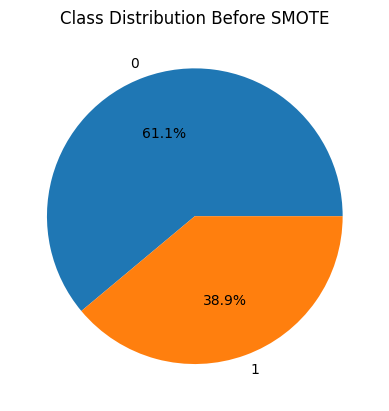

In [7]:
# 5. CLASS DISTRIBUTION BEFORE SMOTE

print("\nClass Distribution:")

print(y.value_counts())

y.value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title(
    "Class Distribution Before SMOTE"
)

plt.ylabel("")

plt.show()

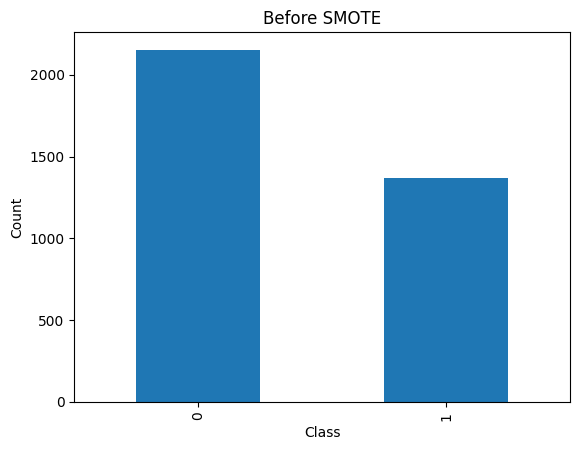

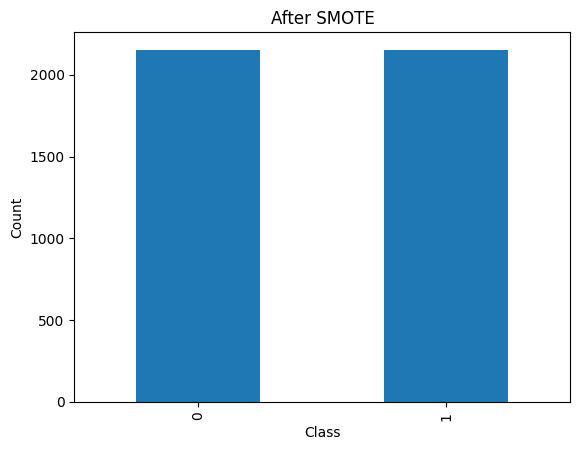

In [8]:
# 6. DISPLAY SMOTE EFFECT

display_imputer = SimpleImputer(
    strategy="mean"
)

X_display = display_imputer.fit_transform(X)

display_scaler = StandardScaler()

X_display = display_scaler.fit_transform(
    X_display
)

display_smote = SMOTE(
    random_state=42
)

X_smote_display, y_smote_display = (
    display_smote.fit_resample(
        X_display,
        y
    )
)

before = y.value_counts()

after = pd.Series(
    y_smote_display
).value_counts()


plt.figure()

before.plot(
    kind="bar"
)

plt.title("Before SMOTE")

plt.xlabel("Class")

plt.ylabel("Count")

plt.show()


plt.figure()

after.plot(
    kind="bar"
)

plt.title("After SMOTE")

plt.xlabel("Class")

plt.ylabel("Count")

plt.show()


In [9]:
# 7. DEFINE MODELS

models = {

    "RF": RandomForestClassifier(
        random_state=42
    ),

    "ET": ExtraTreesClassifier(
        random_state=42
    ),

    "XGB": XGBClassifier(
        eval_metric="logloss",
        random_state=42
    ),

    "LGBM": LGBMClassifier(
        random_state=42,
        verbose=-1
    ),

    "CAT": CatBoostClassifier(
        verbose=0,
        random_state=42
    ),

    "SVM": SVC(
        probability=True,
        random_state=42
    ),

    "KNN": KNeighborsClassifier(),

    "DT": DecisionTreeClassifier(
        random_state=42
    ),

    "GB": GradientBoostingClassifier(
        random_state=42
    ),

    "ADA": AdaBoostClassifier(
        random_state=42
    ),

    "LR": LogisticRegression(
        max_iter=1000,
        random_state=42
    ),

    "MLP": MLPClassifier(
        hidden_layer_sizes=(128, 64, 32),
        max_iter=1000,
        early_stopping=True,
        random_state=42
    )
}


In [10]:
# 8. CREATE PREPROCESSING PIPELINE


def create_pipeline(model):

    pipeline = Pipeline([

        (
            "imputer",
            SimpleImputer(
                strategy="mean"
            )
        ),

        (
            "scaler",
            StandardScaler()
        ),

        (
            "smote",
            SMOTE(
                random_state=42
            )
        ),

        (
            "selector",
            SelectKBest(
                score_func=f_classif,
                k=10
            )
        ),

        (
            "model",
            model
        )

    ])

    return pipeline



In [12]:
# 9. DEEP BELIEF NETWORK


rbm1 = BernoulliRBM(
    n_components=128,
    learning_rate=0.01,
    n_iter=20,
    random_state=42
)

rbm2 = BernoulliRBM(
    n_components=64,
    learning_rate=0.01,
    n_iter=20,
    random_state=42
)

rbm3 = BernoulliRBM(
    n_components=32,
    learning_rate=0.01,
    n_iter=20,
    random_state=42
)

logistic = LogisticRegression(
    max_iter=1000,
    random_state=42
)


dbn_model = Pipeline([

    (
        "imputer",
        SimpleImputer(
            strategy="mean"
        )
    ),

    (
        "scaler",
        StandardScaler()
    ),

    (
        "smote",
        SMOTE(
            random_state=42
        )
    ),

    (
        "selector",
        SelectKBest(
            score_func=f_classif,
            k=10
        )
    ),

    (
        "rbm1",
        rbm1
    ),

    (
        "rbm2",
        rbm2
    ),

    (
        "rbm3",
        rbm3
    ),

    (
        "logistic",
        logistic
    )

])

In [13]:
# 10. STACKING ENSEMBLE


base_models = [

    (
        "rf",
        RandomForestClassifier(
            random_state=42
        )
    ),

    (
        "et",
        ExtraTreesClassifier(
            random_state=42
        )
    ),

    (
        "xgb",
        XGBClassifier(
            eval_metric="logloss",
            random_state=42
        )
    )

]


meta_model = LogisticRegression(
    max_iter=1000
)


stack_classifier = StackingClassifier(

    estimators=base_models,

    final_estimator=meta_model
)


stack_model = create_pipeline(
    stack_classifier
)




Evaluating RF...

Evaluating ET...

Evaluating XGB...

Evaluating LGBM...


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ut


Evaluating CAT...

Evaluating SVM...

Evaluating KNN...

Evaluating DT...

Evaluating GB...

Evaluating ADA...

Evaluating LR...

Evaluating MLP...

Evaluating DBN...

Evaluating STACKING...

MODEL PERFORMANCE COMPARISON

    Model  Accuracy  Precision    Recall        F1       AUC
13  STACK  0.974184   0.961444  0.973025  0.967076  0.998234
4     CAT  0.972199   0.957363  0.972300  0.964635  0.997798
0      RF  0.972199   0.949580  0.981043  0.964926  0.998086
1      ET  0.971348   0.952486  0.975209  0.963644  0.998140
6     KNN  0.971064   0.950544  0.976677  0.963381  0.989960
11    MLP  0.971064   0.952462  0.974487  0.963290  0.992123
2     XGB  0.970780   0.956354  0.969386  0.962763  0.997485
3    LGBM  0.970496   0.953283  0.972297  0.962543  0.998123
9     ADA  0.969645   0.956860  0.965733  0.961206  0.996746
5     SVM  0.969362   0.949142  0.973749  0.961172  0.996254
8      GB  0.969362   0.954295  0.967923  0.960976  0.996776
7      DT  0.965390   0.947182  0.965001  0.9

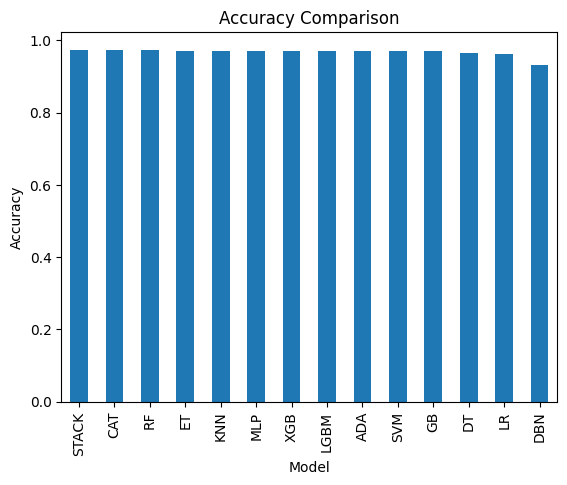

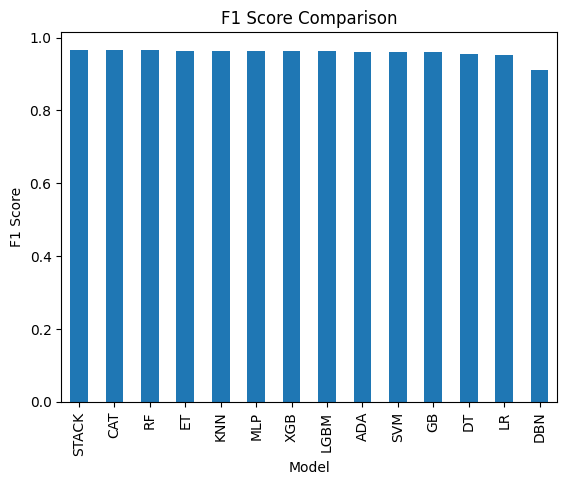

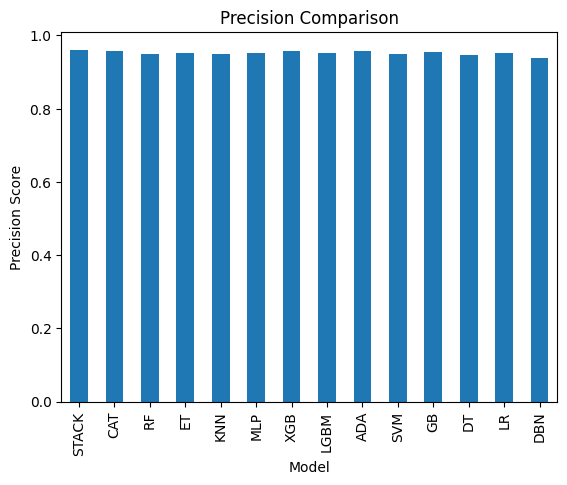

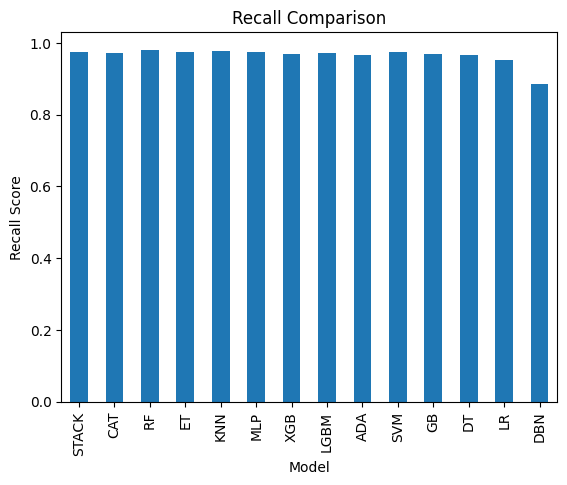

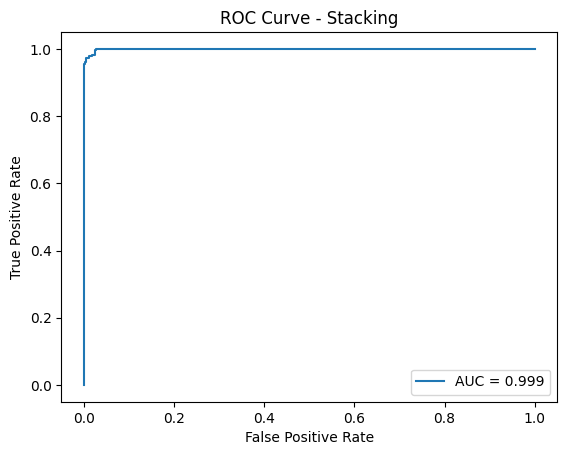

Stacking ROC-AUC: 0.9993

Training Final Calibrated MLP...
Final MLP Model Trained Successfully

Enter Patient Details:

Age: 38
No of Pregnancies: 5
Gestation: 30
BMI: 38
HDL: 30
Family History (0/1): 1
Unexplained Prenatal Loss (0/1): 1
Large Child (0/1): 1
PCOS (0/1): 1
Systolic BP: 150
Diastolic BP: 100
OGTT: 220
Hemoglobin: 10
Sedentary Lifestyle (0/1): 1
Prediabetes (0/1): 1

Original User Input:
    Age  No of Pregnancy  Gestation in previous Pregnancy   BMI   HDL  \
0  38.0              5.0                             30.0  38.0  30.0   

   Family History  unexplained prenetal loss  Large Child or Birth Default  \
0             1.0                        1.0                           1.0   

   PCOS  Sys BP  Dia BP   OGTT  Hemoglobin  Sedentary Lifestyle  Prediabetes  
0   1.0   150.0   100.0  220.0        10.0                  1.0          1.0  

Estimated GDM Risk Score:
96.77%

Result: Higher GDM Risk

This is a model-generated risk estimate and not a medical diagnosis.


In [14]:
# 11. 5-FOLD CROSS VALIDATION
# ============================================================

results = {}


for name, model in models.items():

    print(
        f"\nEvaluating {name}..."
    )

    pipeline = create_pipeline(
        model
    )

    scores = cross_validate(

        pipeline,

        X,

        y,

        cv=5,

        scoring=[
            "accuracy",
            "precision",
            "recall",
            "f1",
            "roc_auc"
        ]

    )

    results[name] = scores


# ============================================================
# 12. DBN CROSS VALIDATION
# ============================================================

print("\nEvaluating DBN...")


scores_dbn = cross_validate(

    dbn_model,

    X,

    y,

    cv=5,

    scoring=[
        "accuracy",
        "precision",
        "recall",
        "f1",
        "roc_auc"
    ]

)


results["DBN"] = scores_dbn


# ============================================================
# 13. STACKING CROSS VALIDATION
# ============================================================

print("\nEvaluating STACKING...")


scores_stack = cross_validate(

    stack_model,

    X,

    y,

    cv=5,

    scoring=[
        "accuracy",
        "precision",
        "recall",
        "f1",
        "roc_auc"
    ]

)


results["STACK"] = scores_stack


# ============================================================
# 14. CREATE RESULT TABLE
# ============================================================

final_results = []


for name, score in results.items():

    final_results.append([

        name,

        np.mean(
            score["test_accuracy"]
        ),

        np.mean(
            score["test_precision"]
        ),

        np.mean(
            score["test_recall"]
        ),

        np.mean(
            score["test_f1"]
        ),

        np.mean(
            score["test_roc_auc"]
        )

    ])


df_results = pd.DataFrame(

    final_results,

    columns=[

        "Model",

        "Accuracy",

        "Precision",

        "Recall",

        "F1",

        "AUC"

    ]

)


df_results = df_results.sort_values(

    by=[
        "Accuracy",
        "F1"
    ],

    ascending=False
)


print("\nMODEL PERFORMANCE COMPARISON\n")

print(df_results)


# ============================================================
# 15. ACCURACY COMPARISON
# ============================================================

df_results.set_index(
    "Model"
)["Accuracy"].plot(
    kind="bar"
)

plt.ylabel("Accuracy")

plt.title(
    "Accuracy Comparison"
)

plt.show()


# ============================================================
# 16. F1 SCORE COMPARISON
# ============================================================

df_results.set_index(
    "Model"
)["F1"].plot(
    kind="bar"
)

plt.ylabel("F1 Score")

plt.title(
    "F1 Score Comparison"
)

plt.show()


# ============================================================
# 17. PRECISION COMPARISON
# ============================================================

df_results.set_index(
    "Model"
)["Precision"].plot(
    kind="bar"
)

plt.ylabel(
    "Precision Score"
)

plt.title(
    "Precision Comparison"
)

plt.show()


# ============================================================
# 18. RECALL COMPARISON
# ============================================================

df_results.set_index(
    "Model"
)["Recall"].plot(
    kind="bar"
)

plt.ylabel(
    "Recall Score"
)

plt.title(
    "Recall Comparison"
)

plt.show()


# ============================================================
# 19. TRAIN TEST SPLIT FOR ROC CURVE
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(

    X,

    y,

    test_size=0.2,

    random_state=42,

    stratify=y

)


# ============================================================
# 20. STACKING ROC CURVE
# ============================================================

stack_model.fit(
    X_train,
    y_train
)


y_prob = stack_model.predict_proba(
    X_test
)[:, 1]


fpr, tpr, thresholds = roc_curve(

    y_test,

    y_prob

)


roc_auc = auc(
    fpr,
    tpr
)


plt.figure()

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {roc_auc:.3f}"
)

plt.xlabel(
    "False Positive Rate"
)

plt.ylabel(
    "True Positive Rate"
)

plt.title(
    "ROC Curve - Stacking"
)

plt.legend()

plt.show()


print(
    "Stacking ROC-AUC:",
    round(
        roc_auc,
        4
    )
)


# ============================================================
# 21. FINAL CALIBRATED MLP MODEL
# ============================================================

final_mlp_pipeline = create_pipeline(

    MLPClassifier(

        hidden_layer_sizes=(
            128,
            64,
            32
        ),

        max_iter=1000,

        early_stopping=True,

        random_state=42

    )

)


mlp_model = CalibratedClassifierCV(

    final_mlp_pipeline,

    method="sigmoid",

    cv=5

)


print(
    "\nTraining Final Calibrated MLP..."
)


mlp_model.fit(
    X,
    y
)


print(
    "Final MLP Model Trained Successfully"
)


# ============================================================
# 22. USER INPUT
# ============================================================

print(
    "\nEnter Patient Details:\n"
)


age = float(
    input("Age: ")
)

preg = float(
    input("No of Pregnancies: ")
)

gest = float(
    input("Gestation: ")
)

bmi = float(
    input("BMI: ")
)

hdl = float(
    input("HDL: ")
)

family = float(
    input(
        "Family History (0/1): "
    )
)

unexplained = float(
    input(
        "Unexplained Prenatal Loss (0/1): "
    )
)

large_child = float(
    input(
        "Large Child (0/1): "
    )
)

pcos = float(
    input(
        "PCOS (0/1): "
    )
)

sys_bp = float(
    input(
        "Systolic BP: "
    )
)

dia_bp = float(
    input(
        "Diastolic BP: "
    )
)

ogtt = float(
    input(
        "OGTT: "
    )
)

hemo = float(
    input(
        "Hemoglobin: "
    )
)

sedentary = float(
    input(
        "Sedentary Lifestyle (0/1): "
    )
)

prediabetes = float(
    input(
        "Prediabetes (0/1): "
    )
)


# ============================================================
# 23. CREATE USER DATA
# ============================================================

user_values = [

    age,

    preg,

    gest,

    bmi,

    hdl,

    family,

    unexplained,

    large_child,

    pcos,

    sys_bp,

    dia_bp,

    ogtt,

    hemo,

    sedentary,

    prediabetes

]


user_data = pd.DataFrame(

    [user_values],

    columns=feature_names

)


print(
    "\nOriginal User Input:"
)

print(
    user_data
)


# ============================================================
# 24. PREDICT GDM RISK
# ============================================================

probabilities = mlp_model.predict_proba(
    user_data
)[0]


class_index = list(
    mlp_model.classes_
).index(1)


gdm_probability = probabilities[
    class_index
]


print(
    "\nEstimated GDM Risk Score:"
)

print(
    f"{gdm_probability * 100:.2f}%"
)


# ============================================================
# 25. FINAL RESULT
# ============================================================

if gdm_probability >= 0.5:

    print(
        "\nResult: Higher GDM Risk"
    )

else:

    print(
        "\nResult: Lower GDM Risk"
    )


print(
    "\nThis is a model-generated risk estimate "
    "and not a medical diagnosis."
)
